# Elevator Scheduling System
## A Discrete-Time Simulation Study

This notebook presents a simulation study of intelligent elevator scheduling algorithms.
We model a building with multiple elevators serving passenger requests, and compare
scheduling strategies in terms of passenger wait times, travel times, and elevator utilisation.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.simulation import run_simulation, generate_input
from src.io.input import parse_csv
from src.scheduler.round_robin import RoundRobin
from src.scheduler.nearest_car import NearestCar
from src.scheduler.nearest_idle import NearestIdle
from src.scheduler.zone import ZoneScheduler

# ── Algorithm registry ──────────────────────────────────────────────────────
# To add a new algorithm: append one entry here. All plots update automatically.
# For algorithms with extra constructor args, use functools.partial.
ALGORITHMS = {
    "Round Robin":        RoundRobin,
    "Nearest Car":        NearestCar,
    "Nearest Idle":       NearestIdle,
    "Zone Scheduler": ZoneScheduler,
}

COLORS = ["#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0", "#00BCD4"]
ALG_COLORS = {name: COLORS[i % len(COLORS)] for i, name in enumerate(ALGORITHMS)}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Problem Statement

Modern buildings require efficient elevator systems to move large numbers of people quickly.
The challenge is to assign passenger requests to elevator cars in a way that minimises:

- **Wait time**: time from a passenger's request until they board an elevator
- **Travel time**: time from boarding until they reach their destination  
- **Total time**: wait time + travel time

### Constraints
- Each elevator has a maximum passenger capacity
- Elevators travel one floor per time tick
- Elevators use a **LOOK policy**: continue in the current direction as long as there are targets (destinations of on-board passengers, or pickup floors of assigned passengers) ahead; only reverse when none remain in that direction
- Passengers who cannot be immediately assigned are queued on a waitlist and retried with priority at the next tick

## 2. System Model

The simulation uses a **discrete-time model**:

| Component | Description |
|-----------|-------------|
| Time      | Integer ticks; one tick = one floor of travel |
| Building  | N floors, M elevators, all starting at floor 0 |
| Passenger | Arrives at `request_time`, at `source` floor, wants to reach `dest` floor |
| Elevator  | State: STOPPED / UP / DOWN; moves 1 floor per tick |

### Elevator Operation (LOOK policy)
Each tick, an elevator:
1. **Picks up** any assigned passengers waiting at its current floor (recording their `entering_time`)
2. **Sets direction** using the LOOK policy:
   - If moving UP: continue up if any on-board passenger's `dest` or any assigned passenger's `source` is above the current floor; otherwise reverse or stop
   - If moving DOWN: mirror of the above
   - If STOPPED: start moving up if any target is above, down if any target is below
3. **Moves** one floor in its current direction
4. **Drops off** any on-board passengers whose `dest` matches the new floor (recording their `exit_time`)

This means an elevator sweeps in one direction, picking up and dropping off everyone along the way, and only turns around when there is no remaining work ahead of it.

### Capacity Model
Capacity is enforced at **scheduling time**, not at boarding time. When a passenger is assigned,
a slot is reserved — the *committed* count (`current + assigned`) must remain below the maximum.
This guarantees no overloading even when passengers board at different future floors.

## 3. Scheduling Algorithms

Four algorithms are implemented. All share the same capacity model and waitlist mechanism:
if no elevator can serve a new passenger, they are placed on a **waitlist** and retried
with priority at the next tick.

| Algorithm | Core idea |
|-----------|-----------|
| Round Robin | Rotating assignment regardless of position |
| Nearest Car | Proximity and direction-aware routing |
| Nearest Idle | Prefer idle elevators; fall back to Nearest Car |
| Zone Scheduler | Static floor zones, one elevator per zone |

### 3.1 Round Robin

Assigns incoming passengers to elevators in a fixed rotating order.

**Procedure:**
1. Maintain a pointer (`elevator_head`) to the current elevator
2. For each new passenger, try the elevator at `head` — if it has capacity, assign and advance the pointer
3. If that elevator is full, try the next one in sequence
4. If all elevators are full, add the passenger to the waitlist

**Key assumptions:**
- Ignores elevator position and direction — purely distributional
- Capacity check: `committed = len(current_passengers) + len(assigned_passengers) < max_passengers`
- Guarantees even load distribution across elevators over time

**Trade-offs:**
- Simple and predictable
- May assign a passenger to a distant elevator when a nearby one is available
- Performs well at low-to-medium loads where most elevators have spare capacity

### 3.2 Nearest Car

Assigns each passenger to the most suitable elevator based on proximity and estimated travel time.

**Procedure:**
1. Filter to elevators with available committed capacity
2. **Priority 1 — heading toward the passenger:**
   - Elevators going UP at or below the passenger's floor
   - Elevators going DOWN at or above the passenger's floor
   - Stopped elevators
   - Sort by: (distance to passenger's source floor, estimated travel time after boarding)
3. **Priority 2 — going away (fallback):**
   - Estimate effective distance = distance to turn floor + distance from turn floor to passenger
   - Sort by: (effective distance, estimated travel time after boarding)
4. If no elevator is available, add to waitlist

**Estimated travel time** for passenger at `source` → `dest` on elevator with turn floor `T`:
- If `dest` is in the same direction as `source` from the elevator: `|dest − source|`
- Otherwise (elevator must pass `source` then reverse): `|T − source| + |T − dest|`

**Key assumptions:**
- The turn floor is estimated from the farthest committed destination in the current direction; the actual turn floor may differ if a higher-priority passenger redirects the elevator mid-route
- Committed capacity used (same as Round Robin) — no look-ahead on future overflow
- Load is not explicitly balanced; may concentrate assignments on well-positioned elevators

**Trade-offs:**
- More intelligent routing typically yields shorter total trip times
- Higher complexity; may behave similarly to Round Robin at low loads where most elevators are idle

### 3.3 Nearest Idle

A variant of Nearest Car that prioritises idle (STOPPED) elevators.

**Procedure:**
1. Filter to elevators with available committed capacity
2. **If any idle elevators exist:** assign to the nearest idle elevator by floor distance
3. **If no idle elevators exist:** fall back to the full Nearest Car algorithm

**Key assumptions:**
- An idle elevator can head directly to the passenger with no detour — the pickup time equals the floor distance exactly
- At low loads most elevators are idle most of the time, so this is usually the primary path
- At high loads idle elevators become scarce and the algorithm degrades toward Nearest Car

**Trade-offs:**
- Tends to produce shorter wait times than Nearest Car at low-to-medium loads
- Does not explicitly balance load; like Nearest Car, may concentrate assignments on a subset of elevators

### 3.4 Zone Scheduler (Static Hard Zones)

Divides the building into fixed vertical zones, one per elevator. Each elevator exclusively serves requests originating in its zone.

**Procedure:**
1. At startup, divide the N floors evenly into M zones (one per elevator)
2. For each incoming passenger, look up which zone their source floor belongs to
3. Assign to that zone's elevator if it has capacity; otherwise waitlist

**Zone assignment** (example: 5 elevators, 60 floors):

| Elevator | Zone |
|----------|------|
| 0 | Floors 1–12 |
| 1 | Floors 13–24 |
| 2 | Floors 25–36 |
| 3 | Floors 37–48 |
| 4 | Floors 49–60 |

**Key assumptions:**
- Hard zones: a passenger is never assigned to an elevator outside their zone, even if neighbouring elevators are idle
- Zones are fixed at construction time based on `num_floors / num_elevators`
- Within a zone the elevator uses the standard LOOK policy

**Trade-offs:**
- Guarantees geographic load distribution — each elevator covers a predictable floor range
- Short wait times when demand is uniform across floors, since each zone elevator stays local
- Degrades under uneven demand: a busy zone builds a long waitlist while elevators in quiet zones sit idle
- No cross-zone fallback, so a single full elevator can strand passengers even when others have spare capacity

## 4. Worked Example

We run both algorithms on the manual input file (`data/input.csv`) and visualise
the elevator trajectories alongside passenger events.

**Plot legend:**
- **Coloured lines**: elevator floor position over time
- **▲ Green triangles**: a passenger boards at this (time, floor)
- **▼ Red triangles**: a passenger exits at this (time, floor)

In [2]:
EXAMPLE_CONFIG = dict(
    num_elevators=3,
    max_passengers=10,
    num_floors=60,
    total_time_slots=100,
)

manual_input = parse_csv("data/input.csv", EXAMPLE_CONFIG["num_floors"])
if manual_input is None:
    print("data/input.csv not found — add your input file to run this section.")
else:
    print(f"Loaded {len(manual_input)} passengers from data/input.csv\n")
    example_results = {}
    for alg_name, alg_class in ALGORITHMS.items():
        r = run_simulation(**EXAMPLE_CONFIG, scheduler_class=alg_class, input_data=manual_input)
        example_results[alg_name] = r
        print(f"{alg_name}: served {r['num_served']}/{r['num_total']} passengers in {r['total_ticks']} ticks")

Parsed 4 rows from 'data/input.csv'
Loaded 4 passengers from data/input.csv

Round Robin: served 4/4 passengers in 100 ticks
Nearest Car: served 4/4 passengers in 100 ticks
Nearest Idle: served 4/4 passengers in 100 ticks
Zone Scheduler: served 4/4 passengers in 107 ticks


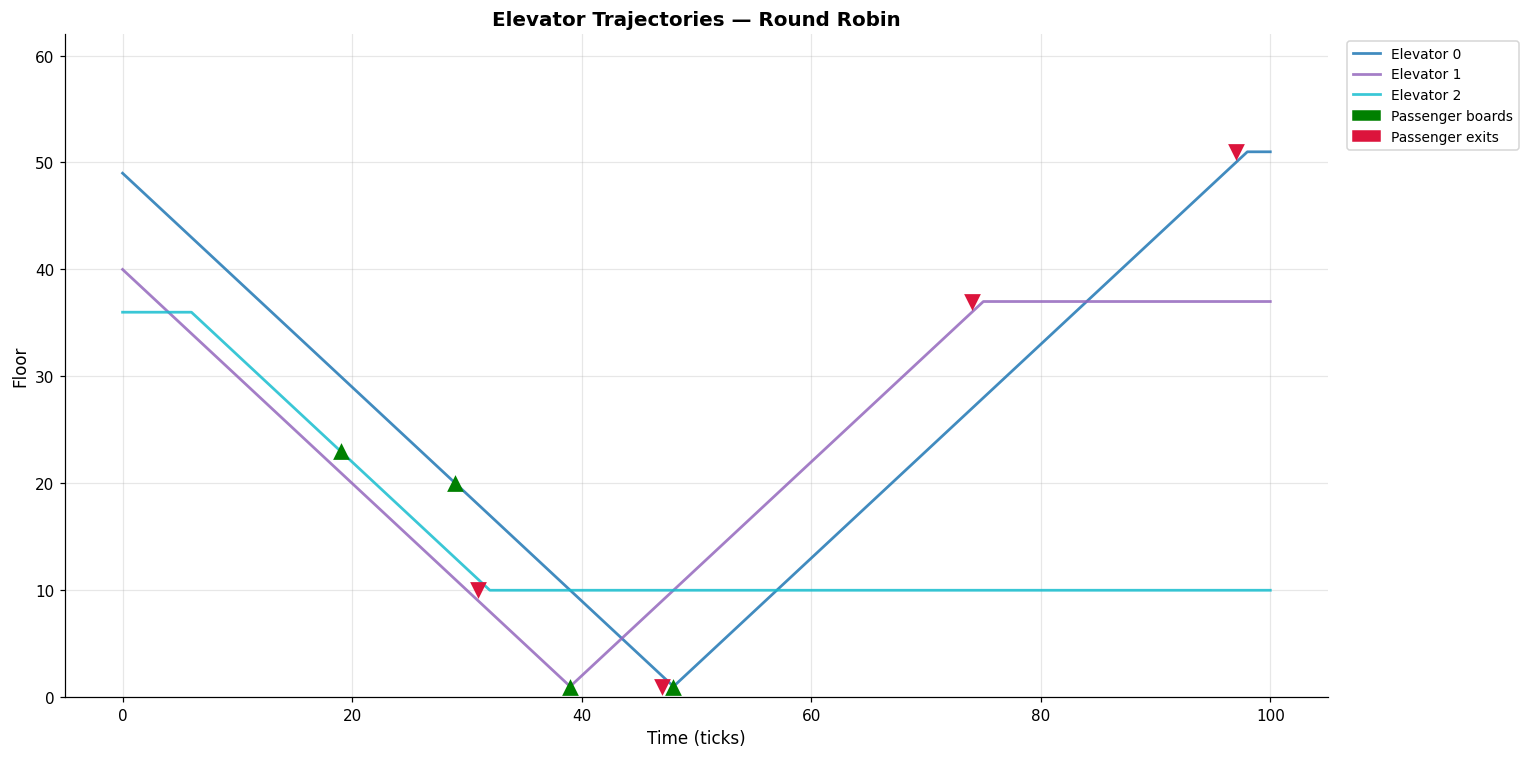

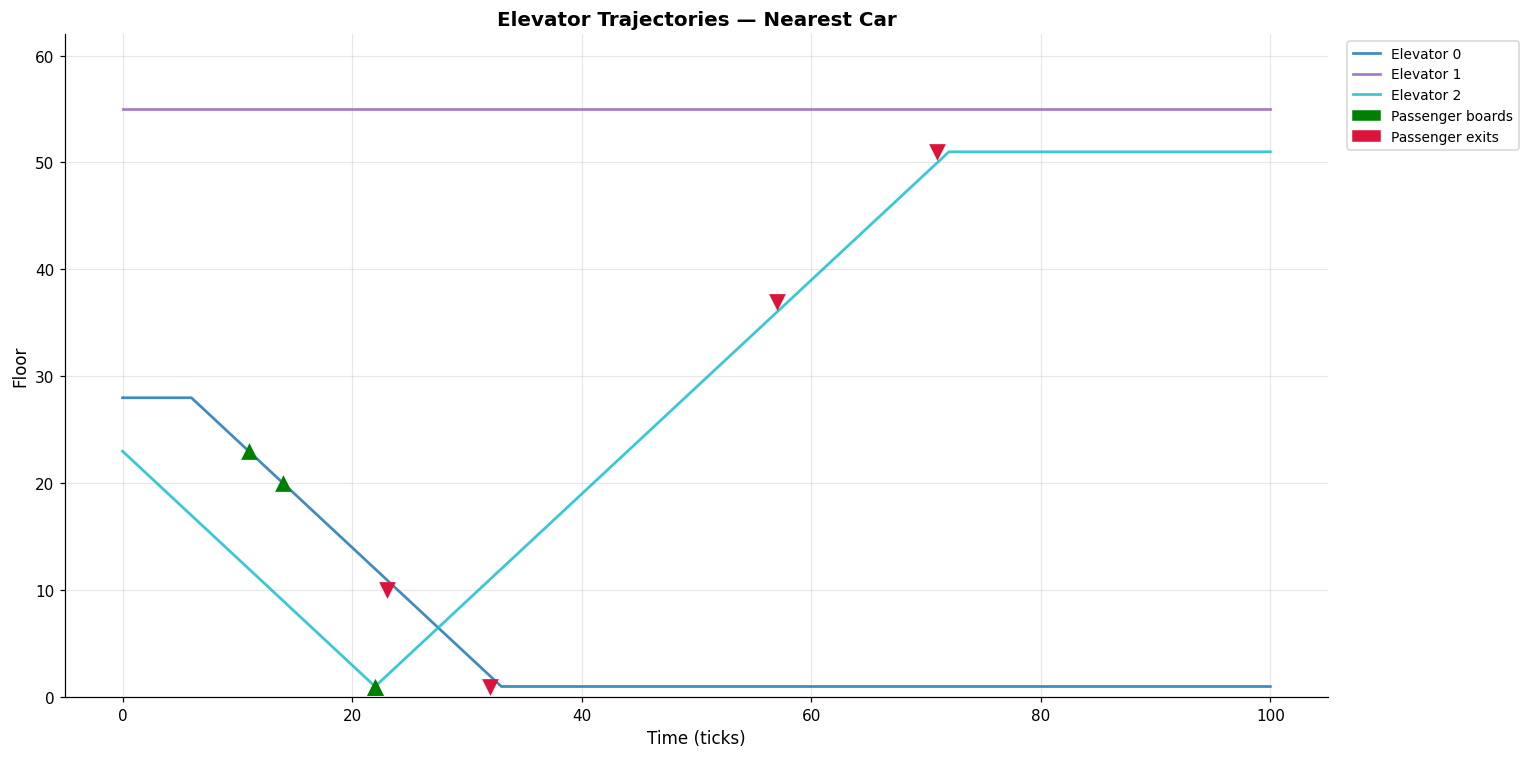

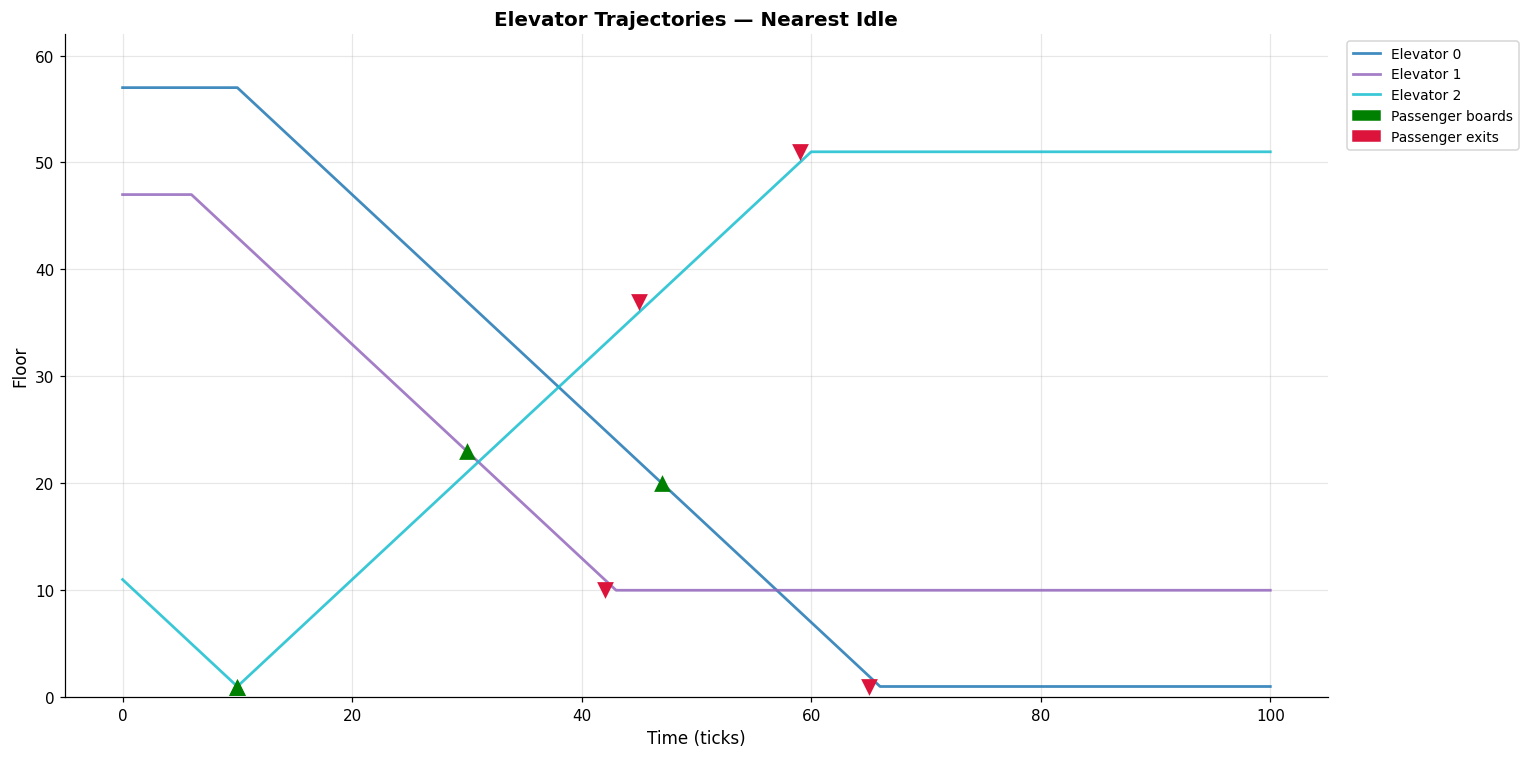

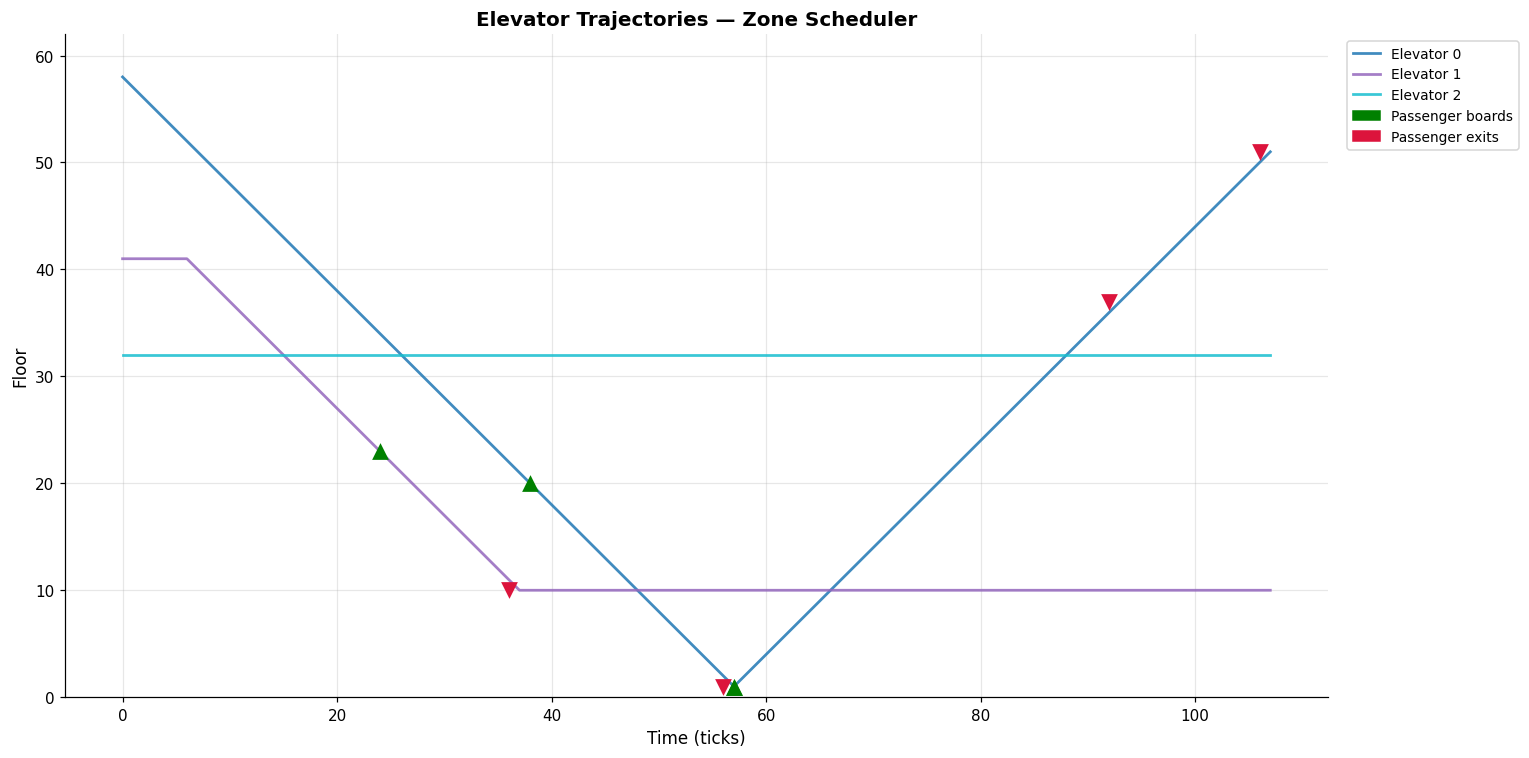

In [3]:
def plot_trajectory(result, title, num_floors):
    positions = result["positions"]
    passengers = result["passengers"]
    num_elevators = len(positions)
    ticks = len(positions[0])

    fig, ax = plt.subplots(figsize=(14, 7))
    cmap = plt.cm.tab10(np.linspace(0, 0.9, num_elevators))

    for i, color in zip(range(num_elevators), cmap):
        ax.plot(range(ticks), positions[i], color=color, linewidth=1.8,
                label=f"Elevator {i}", alpha=0.85)

    for p in passengers:
        if p.entering_time is not None:
            ax.scatter(p.entering_time, p.source, marker="^", color="green",
                       s=120, zorder=6, linewidths=0)
        if p.exit_time is not None:
            ax.scatter(p.exit_time - 1, p.dest, marker="v", color="crimson",
                       s=120, zorder=6, linewidths=0)

    el_handles, el_labels = ax.get_legend_handles_labels()
    board_patch = mpatches.Patch(color="green", label="Passenger boards")
    exit_patch  = mpatches.Patch(color="crimson", label="Passenger exits")
    ax.legend(
        handles=el_handles + [board_patch, exit_patch],
        labels=el_labels + ["Passenger boards", "Passenger exits"],
        bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9,
    )
    ax.set_xlabel("Time (ticks)", fontsize=11)
    ax.set_ylabel("Floor", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, num_floors + 2)
    plt.tight_layout()
    plt.show()


if manual_input is not None:
    for alg_name, result in example_results.items():
        plot_trajectory(result, f"Elevator Trajectories — {alg_name}", EXAMPLE_CONFIG["num_floors"])

In [4]:
def print_comparison_table(results_dict):
    metrics  = [("wait_times", "Wait Time"), ("travel_times", "Travel Time"), ("total_times", "Total Time")]
    stat_fns = [("min", np.min), ("max", np.max), ("mean", np.mean), ("median", np.median), ("std", np.std)]

    alg_names = list(results_dict.keys())
    col_w = 18
    print(f"{'':32}", end="")
    for name in alg_names:
        print(f"{name:>{col_w}}", end="")
    print()
    print("─" * (32 + col_w * len(alg_names)))

    for metric_key, metric_label in metrics:
        print(f"\n  {metric_label}")
        for stat_name, stat_fn in stat_fns:
            print(f"    {stat_name:<28}", end="")
            for name in alg_names:
                vals = results_dict[name][metric_key]
                val = float(stat_fn(vals)) if vals else float("nan")
                print(f"{val:>{col_w}.1f}", end="")
            print()

    print(f"\n{'─' * (32 + col_w * len(alg_names))}")
    print(f"\n  Elevator Utilisation")
    print(f"    {'active fraction':<28}", end="")
    for name in alg_names:
        print(f"{results_dict[name]['active_fraction']:>{col_w}.1%}", end="")
    print()
    print(f"    {'avg load (passengers/tick)':<28}", end="")
    for name in alg_names:
        print(f"{results_dict[name]['avg_load']:>{col_w}.2f}", end="")
    print()


if manual_input is not None:
    print_comparison_table(example_results)

                                       Round Robin       Nearest Car      Nearest Idle    Zone Scheduler
────────────────────────────────────────────────────────────────────────────────────────────────────────

  Wait Time
    min                                       13.0               4.0              10.0              18.0
    max                                       48.0              22.0              37.0              57.0
    mean                                      29.8              13.2              20.2              40.0
    median                                    29.0              13.5              17.0              42.5
    std                                       14.3               8.8              11.2              17.4

  Travel Time
    min                                       13.0              13.0              13.0              13.0
    max                                       50.0              50.0              50.0              50.0
    mean                   

## 5. Stochastic Comparison

We sweep the passenger arrival load from low to high and measure how each algorithm performs.
For each load value we run multiple independent trials (each with a fresh random seed)
and report the mean and 95% confidence interval across trials.

**Setup:**
- Load = expected passengers arriving per floor per time slot  
- Each data point is the mean of 500 independent trials
- All other parameters held fixed (see `SWEEP_CONFIG`)

In [5]:
SWEEP_CONFIG = dict(
    num_elevators=5,
    max_passengers=10,
    num_floors=60,
    total_time_slots=100,
)
LOAD_VALUES  = [0.02, 0.05, 0.08, 0.12, 0.16, 0.20, 0.25, 0.30, 0.40, 0.50, 0.65, 0.80, 1.00]
NUM_TRIALS   = 500


def run_load_sweep(load_values, num_trials, config):
    keys  = ["wait_times", "travel_times", "total_times", "active_fraction", "avg_load"]
    sweep = {alg: {k: {"mean": [], "ci": []} for k in keys} for alg in ALGORITHMS}

    for load in load_values:
        trial = {alg: {k: [] for k in keys} for alg in ALGORITHMS}

        for _ in range(num_trials):
            input_data = generate_input(config["num_floors"], config["total_time_slots"], load)
            for alg_name, alg_class in ALGORITHMS.items():
                r = run_simulation(**config, scheduler_class=alg_class, input_data=input_data)
                for k in ["active_fraction", "avg_load"]:
                    trial[alg_name][k].append(r[k])
                for k in ["wait_times", "travel_times", "total_times"]:
                    if r[k]:
                        trial[alg_name][k].append(float(np.mean(r[k])))

        for alg_name in ALGORITHMS:
            for k in keys:
                vals = np.array(trial[alg_name][k])
                if len(vals):
                    mean = float(np.mean(vals))
                    ci   = float(1.96 * np.std(vals) / np.sqrt(len(vals)))
                else:
                    mean, ci = float("nan"), float("nan")
                sweep[alg_name][k]["mean"].append(mean)
                sweep[alg_name][k]["ci"].append(ci)

    return sweep


print("Running load sweep (this may take a moment)...")
load_sweep = run_load_sweep(LOAD_VALUES, NUM_TRIALS, SWEEP_CONFIG)
print("Done.")

Running load sweep (this may take a moment)...
Done.


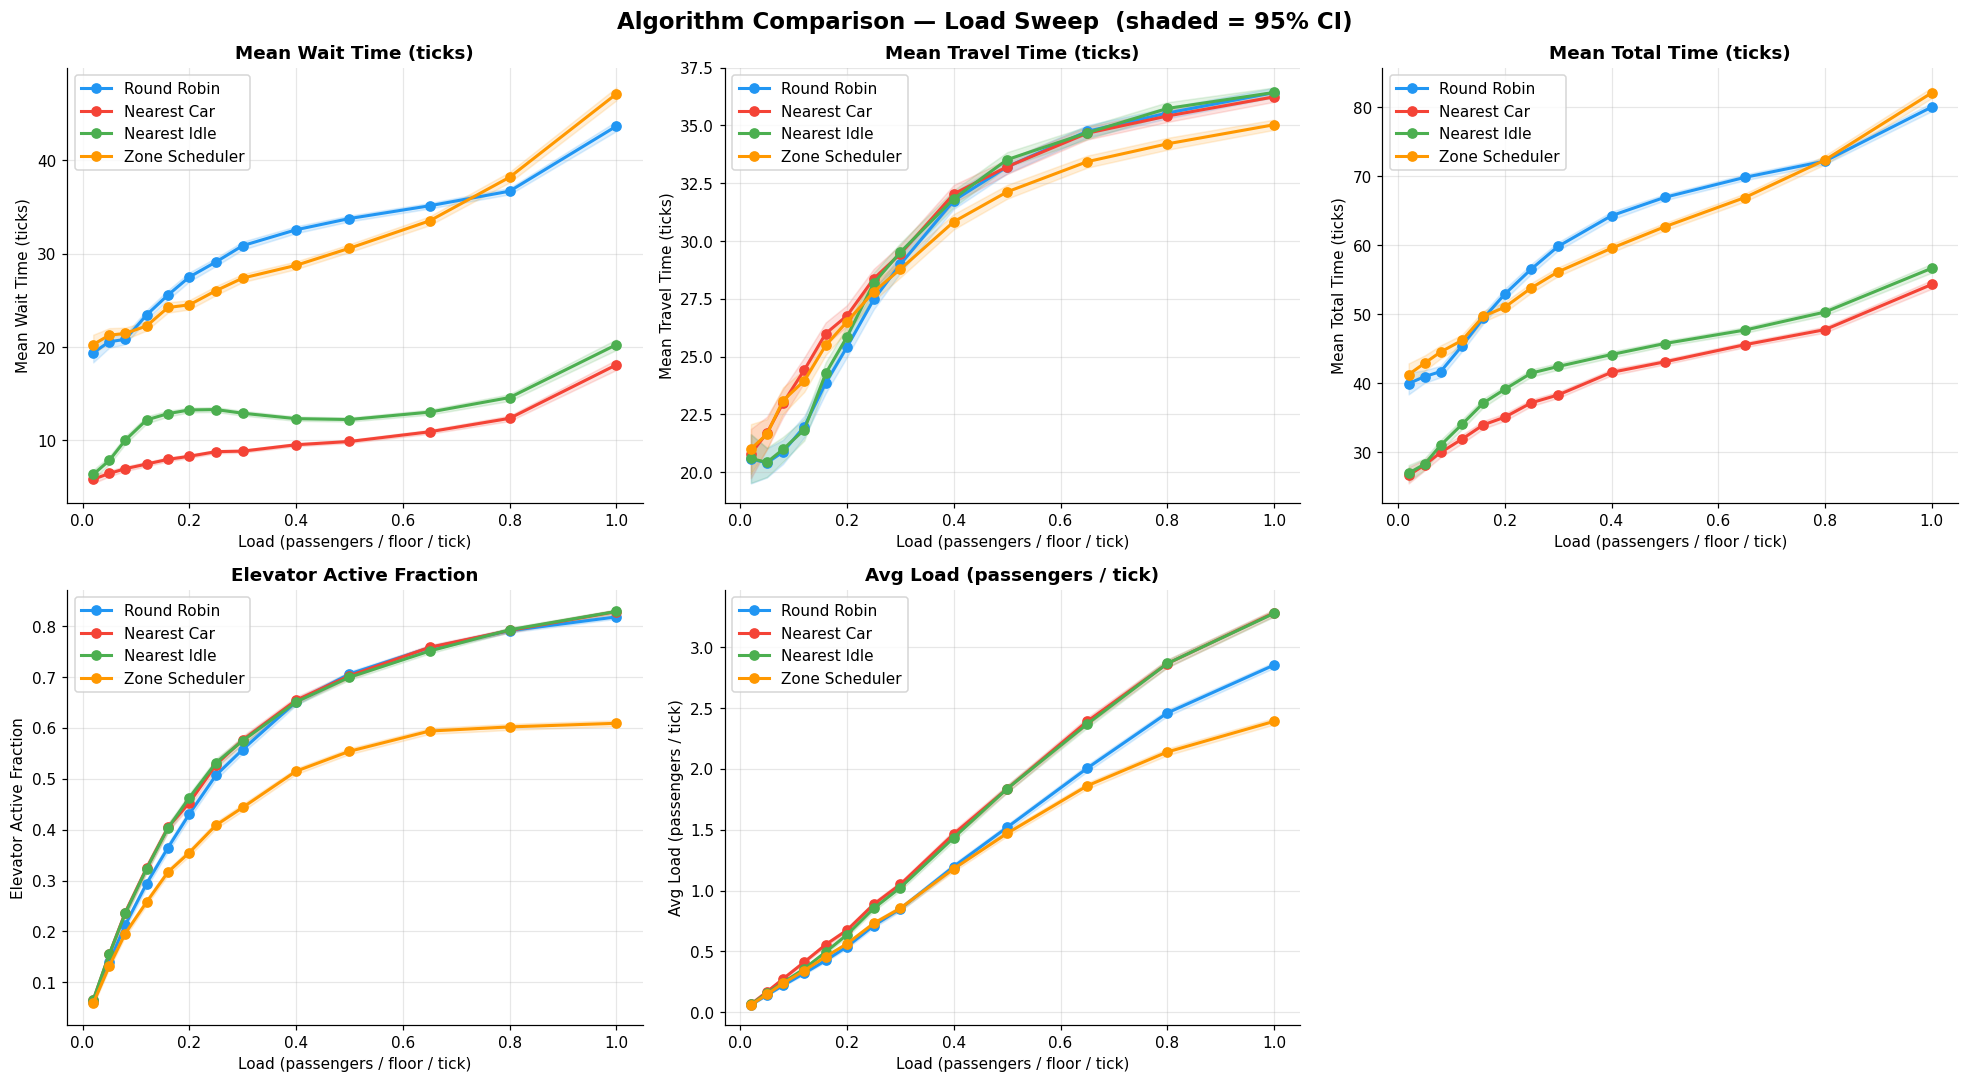

In [6]:
def plot_load_sweep(load_values, sweep_results):
    panels = [
        ("wait_times",      "Mean Wait Time (ticks)"),
        ("travel_times",    "Mean Travel Time (ticks)"),
        ("total_times",     "Mean Total Time (ticks)"),
        ("active_fraction", "Elevator Active Fraction"),
        ("avg_load",        "Avg Load (passengers / tick)"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes_flat = axes.flatten()

    for idx, (key, ylabel) in enumerate(panels):
        ax = axes_flat[idx]
        for alg_name in ALGORITHMS:
            means = np.array(sweep_results[alg_name][key]["mean"])
            cis   = np.array(sweep_results[alg_name][key]["ci"])
            color = ALG_COLORS[alg_name]
            ax.plot(load_values, means, marker="o", label=alg_name, color=color, linewidth=2)
            ax.fill_between(load_values, means - cis, means + cis, color=color, alpha=0.15)
        ax.set_xlabel("Load (passengers / floor / tick)")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel, fontweight="bold")
        ax.legend()

    axes_flat[-1].set_visible(False)
    fig.suptitle("Algorithm Comparison — Load Sweep  (shaded = 95% CI)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_load_sweep(LOAD_VALUES, load_sweep)

## 6. Parameter Sensitivity

We fix the load and vary two system parameters independently to understand how each
algorithm responds to changes in building configuration.

**Questions explored:**
- How does performance scale with the **number of elevators**?
- How does performance scale with the **number of floors**?

In [7]:
SENSITIVITY_BASE = dict(
    num_elevators=5,
    max_passengers=10,
    num_floors=60,
    total_time_slots=100,
)
FIXED_LOAD           = 0.1
ELEVATOR_VALUES      = [2, 4, 6, 8, 10]
FLOOR_VALUES         = [20, 40, 60, 80]
NUM_SENS_TRIALS      = 500


def run_param_sweep(param_name, param_values, base_config, load, num_trials):
    """Vary a single parameter and return mean ± 95% CI of total time per algorithm."""
    sweep = {alg: {"mean": [], "ci": []} for alg in ALGORITHMS}

    for val in param_values:
        config = {**base_config, param_name: val}
        trial_totals = {alg: [] for alg in ALGORITHMS}

        for _ in range(num_trials):
            num_floors = config["num_floors"]
            input_data = generate_input(num_floors, config["total_time_slots"], load)
            for alg_name, alg_class in ALGORITHMS.items():
                r = run_simulation(**config, scheduler_class=alg_class, input_data=input_data)
                if r["total_times"]:
                    trial_totals[alg_name].append(float(np.mean(r["total_times"])))

        for alg_name in ALGORITHMS:
            vals = np.array(trial_totals[alg_name])
            if len(vals):
                mean = float(np.mean(vals))
                ci   = float(1.96 * np.std(vals) / np.sqrt(len(vals)))
            else:
                mean, ci = float("nan"), float("nan")
            sweep[alg_name]["mean"].append(mean)
            sweep[alg_name]["ci"].append(ci)

    return sweep


print("Running elevator sensitivity sweep...")
elev_sweep = run_param_sweep("num_elevators", ELEVATOR_VALUES, SENSITIVITY_BASE, FIXED_LOAD, NUM_SENS_TRIALS)
print("Running floor sensitivity sweep...")
floor_sweep = run_param_sweep("num_floors", FLOOR_VALUES, SENSITIVITY_BASE, FIXED_LOAD, NUM_SENS_TRIALS)
print("Done.")

Running elevator sensitivity sweep...
Running floor sensitivity sweep...
Done.


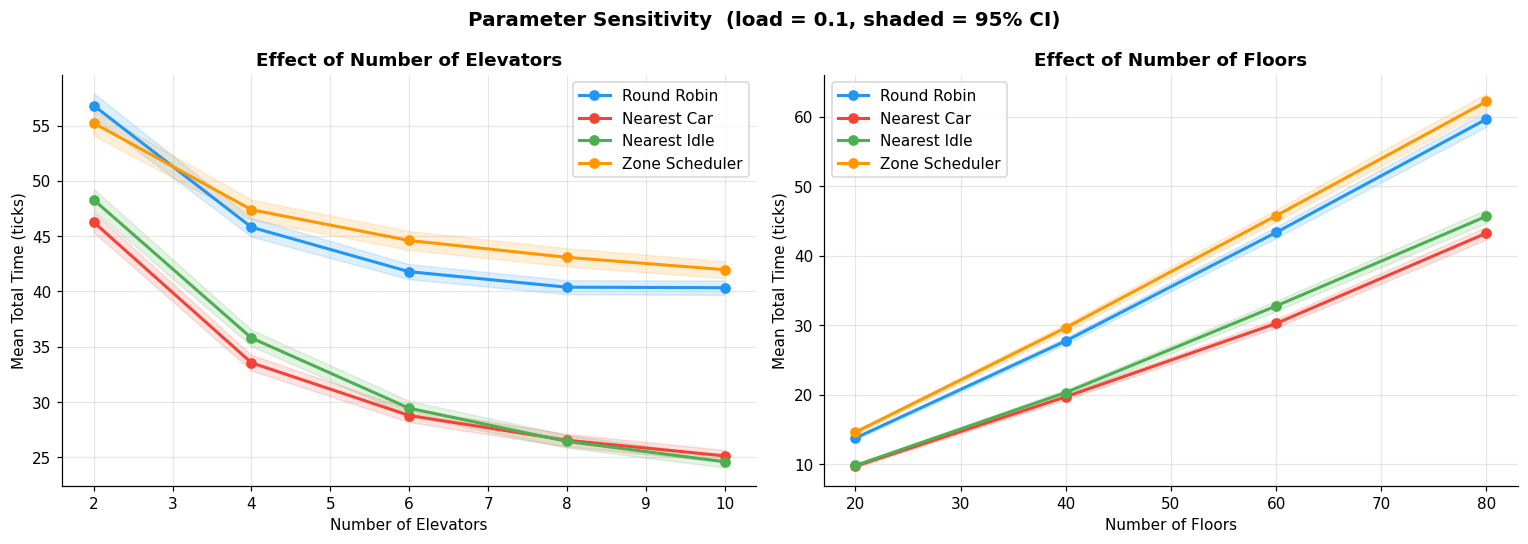

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for alg_name in ALGORITHMS:
    means = np.array(elev_sweep[alg_name]["mean"])
    cis   = np.array(elev_sweep[alg_name]["ci"])
    color = ALG_COLORS[alg_name]
    ax.plot(ELEVATOR_VALUES, means, marker="o", label=alg_name, color=color, linewidth=2)
    ax.fill_between(ELEVATOR_VALUES, means - cis, means + cis, color=color, alpha=0.15)
ax.set_xlabel("Number of Elevators")
ax.set_ylabel("Mean Total Time (ticks)")
ax.set_title("Effect of Number of Elevators", fontweight="bold")
ax.legend()

ax = axes[1]
for alg_name in ALGORITHMS:
    means = np.array(floor_sweep[alg_name]["mean"])
    cis   = np.array(floor_sweep[alg_name]["ci"])
    color = ALG_COLORS[alg_name]
    ax.plot(FLOOR_VALUES, means, marker="o", label=alg_name, color=color, linewidth=2)
    ax.fill_between(FLOOR_VALUES, means - cis, means + cis, color=color, alpha=0.15)
ax.set_xlabel("Number of Floors")
ax.set_ylabel("Mean Total Time (ticks)")
ax.set_title("Effect of Number of Floors", fontweight="bold")
ax.legend()

fig.suptitle(f"Parameter Sensitivity  (load = {FIXED_LOAD}, shaded = 95% CI)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Summary & Insights

### What to look for

**Load vs Performance**
- At low loads all algorithms perform similarly — elevators are mostly idle and respond quickly
- As load increases, proximity-aware algorithms (Nearest Car, Nearest Idle), elevators sweep efficiently and pick up passengers along the way
- Round Robin distributes load evenly but routes elevators inefficiently; it degrades more gracefully under saturation than proximity-based algorithms that can concentrate assignments
- Zone Scheduler performs well at moderate loads with uniform demand; under high or uneven load it is hurt by the hard zone constraint — passengers wait even when neighbouring elevators are free

**Motion Policy Impact**
- The elevator direction policy (continue in current direction until no targets remain, then reverse) significantly benefits proximity-aware algorithms
- Nearest Car and Nearest Idle improve substantially because their turn-floor estimates align with how elevators actually move
- Round Robin is unaffected — it ignores elevator position entirely

**Number of Elevators**
- Load-balancing algorithms (Round Robin, Zone) benefit most from additional elevators since they actively use the extra capacity
- Proximity-based algorithms (Nearest Car, Nearest Idle) may not fully utilise extra elevators — they concentrate assignments on well-positioned cars, leaving others idle
- Diminishing returns set in for all algorithms as the fleet grows relative to demand

**Number of Floors**
- Travel times grow with building height regardless of algorithm
- The advantage of proximity-aware scheduling grows with taller buildings — the cost of a poorly chosen assignment (wrong zone or wrong direction) increases with distance

### Extensibility

To add a new scheduling algorithm:
1. Implement the `Scheduler` abstract base class in `src/scheduler/`
2. Add a single entry to the `ALGORITHMS` dictionary in **Cell 2** of this notebook

All trajectory plots, comparison tables, load sweeps, and sensitivity charts regenerate automatically.